# age=40 이상 현상 원인 분석

> 문제: 히스토그램에서 미인증 유저의 age=40이 비정상적으로 많음  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_excel('../Dataset/Membership.xlsx')

# 편의용 파생 컬럼
df['verified_label'] = df['is_user_verified'].fillna('NaN')
df['gender_label']   = df['gender'].fillna('NaN')
df['is_ios']         = df['billing_method'] == 140   # Apple App Store 결제

verified   = df[df['is_user_verified'] == 'Y']
unverified = df[df['is_user_verified'] == 'N']

print(f'전체: {len(df):,}건 | 인증(Y): {len(verified):,}건 | 미인증(N): {len(unverified):,}건')

전체: 18,183건 | 인증(Y): 13,487건 | 미인증(N): 4,096건


---
1. 문제 확인 — age 분포에서 40세 이상 현상

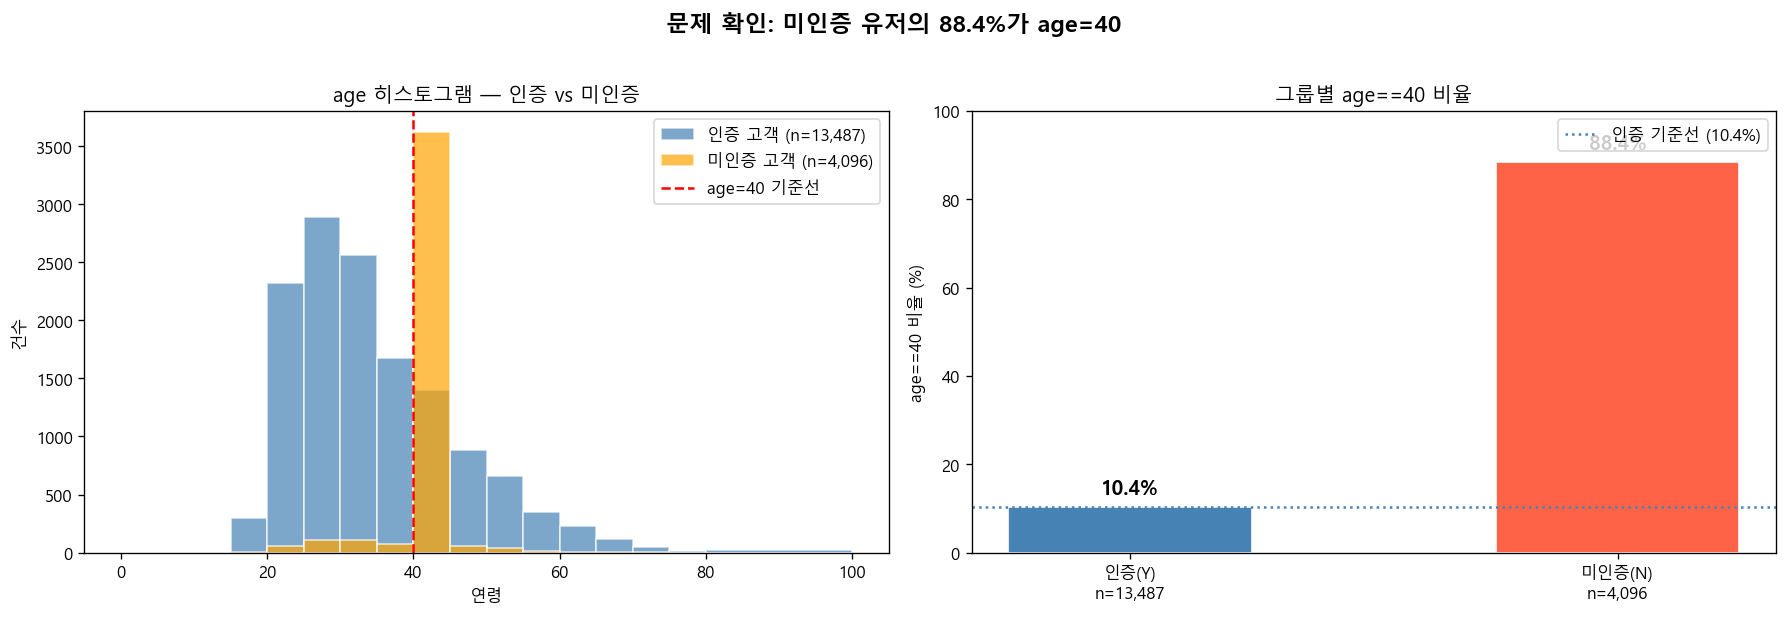

In [3]:
# 인증/미인증 별 age 분포를 겹쳐서 그림
age_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 100]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 왼쪽: 히스토그램 (원래 문제 그래프 재현)
ax = axes[0]
ax.hist(verified['age'].dropna(),   bins=age_bins, alpha=0.7, color='steelblue', label=f'인증 고객 (n={len(verified):,})', edgecolor='white')
ax.hist(unverified['age'].dropna(), bins=age_bins, alpha=0.7, color='orange',    label=f'미인증 고객 (n={len(unverified):,})', edgecolor='white')
ax.set_xlabel('연령')
ax.set_ylabel('건수')
ax.set_title('age 히스토그램 — 인증 vs 미인증')
ax.legend()
ax.axvline(40, color='red', linestyle='--', linewidth=1.5, label='age=40 기준선')
ax.legend()

# 오른쪽: age==40 비율 비교
ax2 = axes[1]
groups = ['인증(Y)\nn=13,487', '미인증(N)\nn=4,096']
age40_pct = [
    (verified['age'] == 40).sum() / len(verified) * 100,
    (unverified['age'] == 40).sum() / len(unverified) * 100
]
bars = ax2.bar(groups, age40_pct, color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
ax2.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=12, fontweight='bold')
ax2.set_ylabel('age==40 비율 (%)')
ax2.set_title('그룹별 age==40 비율')
ax2.set_ylim(0, 100)
ax2.axhline(10.4, color='steelblue', linestyle=':', linewidth=1.5, label='인증 기준선 (10.4%)')
ax2.legend()

plt.suptitle('문제 확인: 미인증 유저의 88.4%가 age=40', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **관찰**: 인증 유저 중 age=40은 **10.4%** (자연스러운 비율)  
> 미인증 유저 중 age=40은 **88.4%** → 명백한 이상값

---
## 2. 데이터 명세서 확인 — 미인증시 성별/연령 부정확

In [4]:
desc = pd.read_excel('../Dataset/Membership_Description.xlsx')
# is_user_verified 행만 출력
desc[desc['Name'] == 'is_user_verified'][['Name', 'Description', 'Example']]

,Name,Description,Example
9,is_user_verified,본인인증여부 (미인증시 성별/연령 부정확),Y


> **핵심 근거**: Membership_Description에 명시  
> `is_user_verified` → **"본인인증여부 (미인증시 성별/연령 부정확)"**  
> 즉, 미인증 유저의 age/gender는 신뢰할 수 없는 기본값임을 데이터 설계 단계에서 이미 인정

---
## 3. gender='N' 기본값도 함께 확인

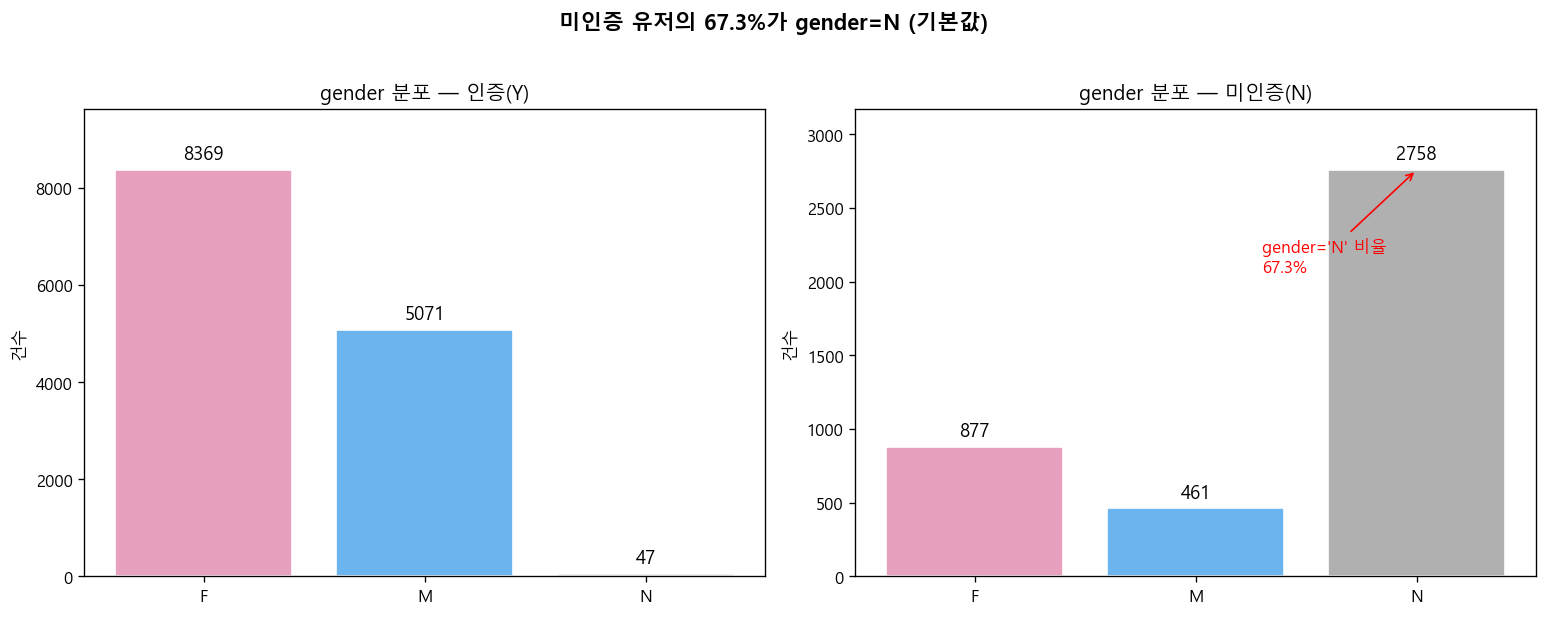

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette = {'F': '#E8A0BF', 'M': '#6CB4EE', 'N': '#B0B0B0'}

for ax, (grp, label) in zip(axes, [(verified, '인증(Y)'), (unverified, '미인증(N)')]):
    counts = grp['gender'].value_counts(dropna=False).reindex(['F', 'M', 'N'], fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=[palette[g] for g in counts.index],
                  edgecolor='white')
    ax.bar_label(bars, padding=4, fontsize=11)
    ax.set_title(f'gender 분포 — {label}')
    ax.set_ylabel('건수')
    ax.set_ylim(0, counts.max() * 1.15)

# 비율 주석
unv_gN = (unverified['gender'] == 'N').sum()
axes[1].annotate(f"gender='N' 비율\n{unv_gN/len(unverified)*100:.1f}%",
                 xy=(2, unv_gN), xytext=(1.3, unv_gN * 0.75),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=10)

plt.suptitle('미인증 유저의 67.3%가 gender=N (기본값)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. 원인 1 — iOS 앱스토어 결제 (billing_method=140)

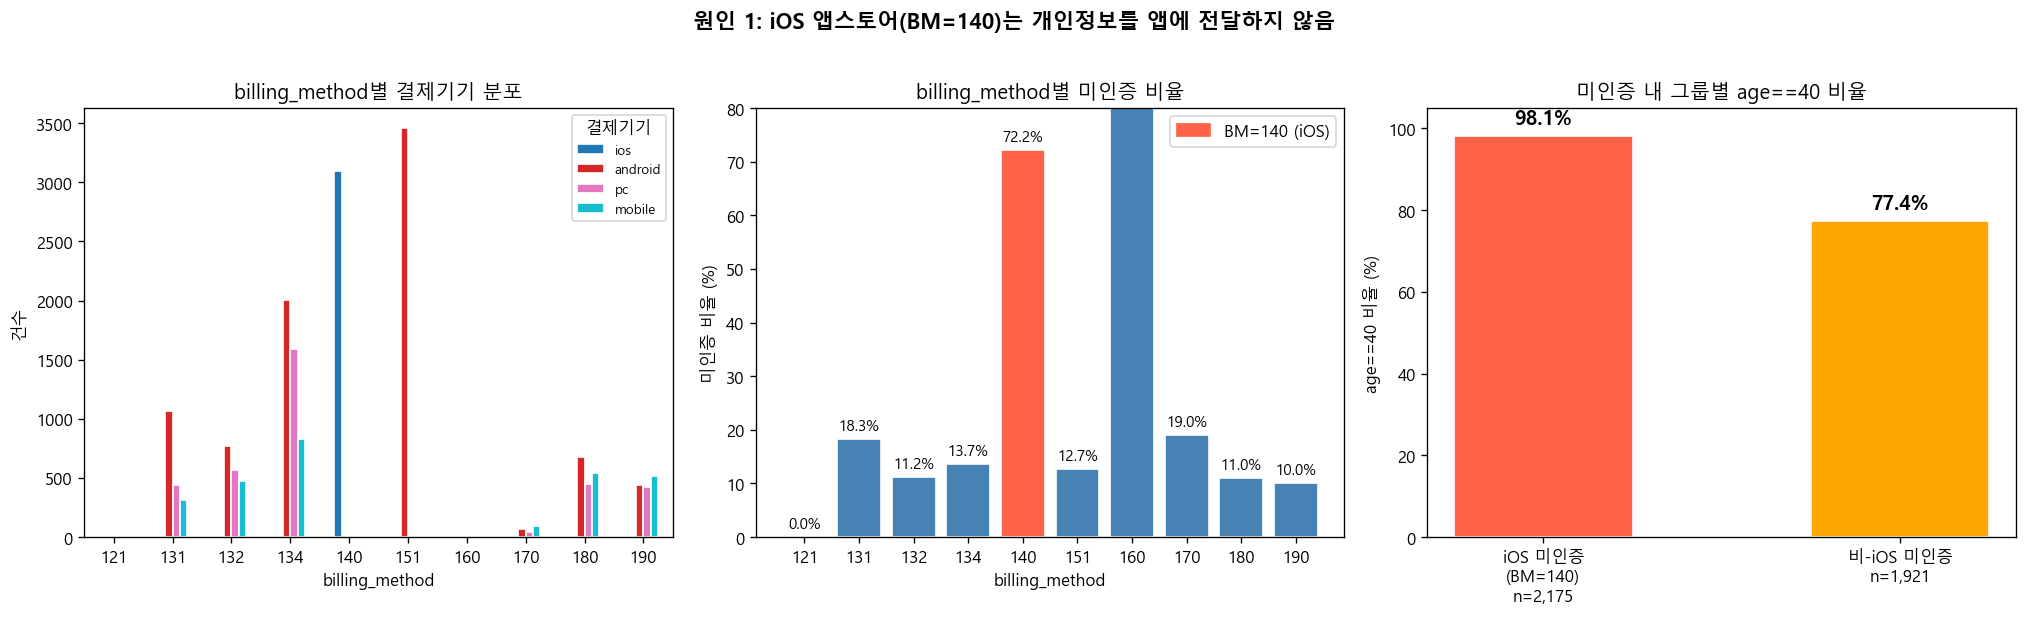

In [6]:
# billing_method=140은 100% iOS
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 그래프 1: billing_method별 payment_device (140이 iOS 전용임을 확인)
ax = axes[0]
bm_device = pd.crosstab(df['billing_method'], df['payment_device'])
# 주요 payment_device만
bm_device_top = bm_device[['ios', 'android', 'pc', 'mobile']].copy()
bm_device_top.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('billing_method별 결제기기 분포')
ax.set_xlabel('billing_method')
ax.set_ylabel('건수')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='결제기기', fontsize=8)

# 그래프 2: billing_method별 미인증 비율
ax2 = axes[1]
bm_verify = df.groupby('billing_method')['is_user_verified'].apply(
    lambda x: (x == 'N').sum() / x.notna().sum() * 100
).reset_index()
bm_verify.columns = ['billing_method', 'unverified_pct']
colors = ['tomato' if bm == 140 else 'steelblue' for bm in bm_verify['billing_method']]
bars2 = ax2.bar(bm_verify['billing_method'].astype(str), bm_verify['unverified_pct'],
                color=colors, edgecolor='white')
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax2.set_title('billing_method별 미인증 비율')
ax2.set_xlabel('billing_method')
ax2.set_ylabel('미인증 비율 (%)')
ax2.set_ylim(0, 80)
red_patch = mpatches.Patch(color='tomato', label='BM=140 (iOS)')
ax2.legend(handles=[red_patch])

# 그래프 3: iOS vs 비iOS 미인증에서 age==40 비율
ax3 = axes[2]
ios_unv  = unverified[unverified['billing_method'] == 140]
nios_unv = unverified[unverified['billing_method'] != 140]
labels = ['iOS 미인증\n(BM=140)\nn=2,175', '비-iOS 미인증\nn=1,921']
pcts   = [
    (ios_unv['age'] == 40).sum()  / len(ios_unv)  * 100,
    (nios_unv['age'] == 40).sum() / len(nios_unv) * 100
]
bars3 = ax3.bar(labels, pcts, color=['tomato', 'orange'], edgecolor='white', width=0.5)
ax3.bar_label(bars3, fmt='%.1f%%', padding=4, fontsize=12, fontweight='bold')
ax3.set_title('미인증 내 그룹별 age==40 비율')
ax3.set_ylabel('age==40 비율 (%)')
ax3.set_ylim(0, 105)

plt.suptitle('원인 1: iOS 앱스토어(BM=140)는 개인정보를 앱에 전달하지 않음', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> `billing_method=140`은 **Apple App Store 인앱결제** 전용 (payment_device가 100% ios)  
> 애플 정책상 앱 서비스에 구독자의 성별/생년월일을 제공하지 않음  
> → 시스템이 자동으로 `is_user_verified=N`, `gender=N`, `age=40` 할당  
> iOS 미인증의 **98.1%**가 age=40

---
## 5. 원인 2 — 비-iOS 결제이지만 본인인증 미실시

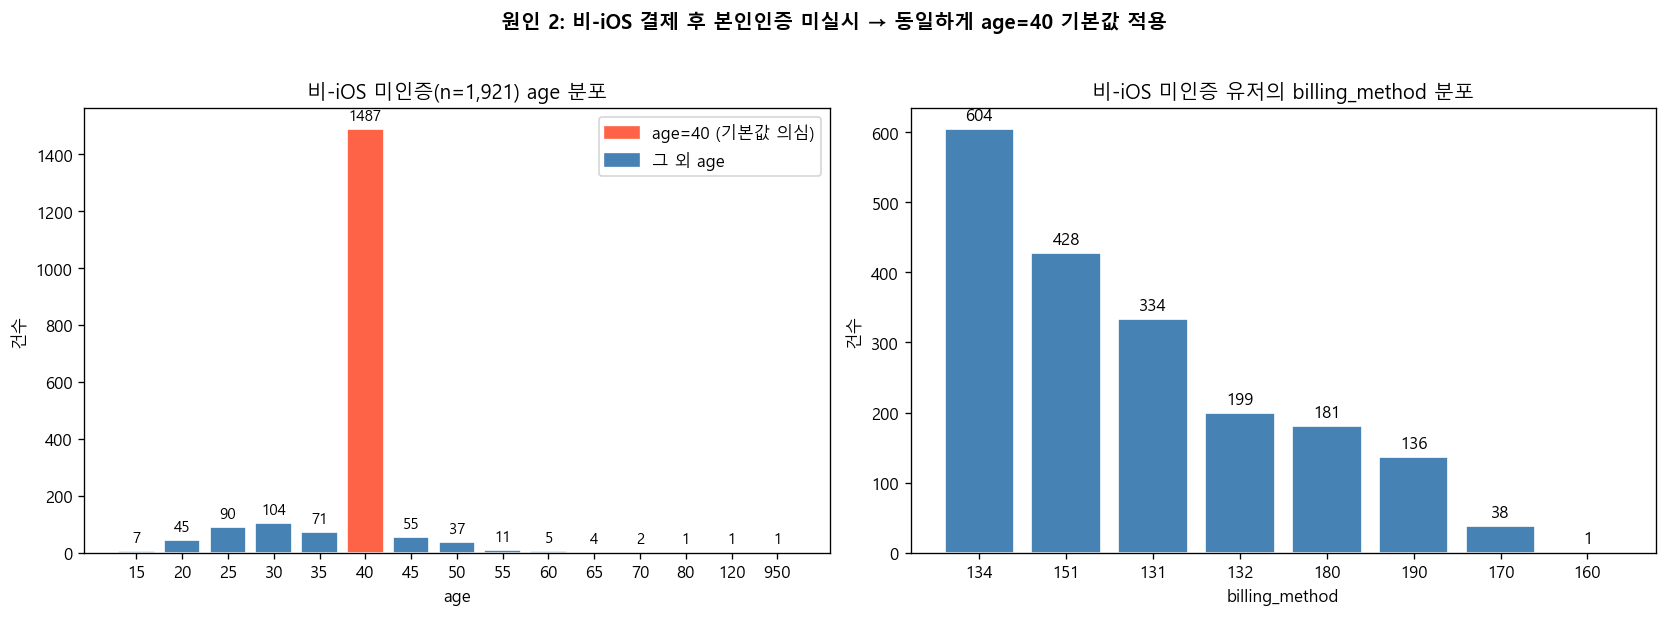

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 비-iOS 미인증 유저의 age 분포
ax = axes[0]
age_counts = nios_unv['age'].value_counts().sort_index()
colors_bar = ['tomato' if a == 40 else 'steelblue' for a in age_counts.index]
bars = ax.bar(age_counts.index.astype(int).astype(str), age_counts.values,
              color=colors_bar, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('비-iOS 미인증(n=1,921) age 분포')
ax.set_xlabel('age')
ax.set_ylabel('건수')
red_patch  = mpatches.Patch(color='tomato',    label='age=40 (기본값 의심)')
blue_patch = mpatches.Patch(color='steelblue', label='그 외 age')
ax.legend(handles=[red_patch, blue_patch])

# billing_method별 비-iOS 미인증 분포
ax2 = axes[1]
nios_bm = nios_unv['billing_method'].value_counts()
bars2 = ax2.bar(nios_bm.index.astype(str), nios_bm.values, color='steelblue', edgecolor='white')
ax2.bar_label(bars2, padding=3, fontsize=10)
ax2.set_title('비-iOS 미인증 유저의 billing_method 분포')
ax2.set_xlabel('billing_method')
ax2.set_ylabel('건수')

plt.suptitle('원인 2: 비-iOS 결제 후 본인인증 미실시 → 동일하게 age=40 기본값 적용', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. 미인증 4,096명 전체 케이스 분류

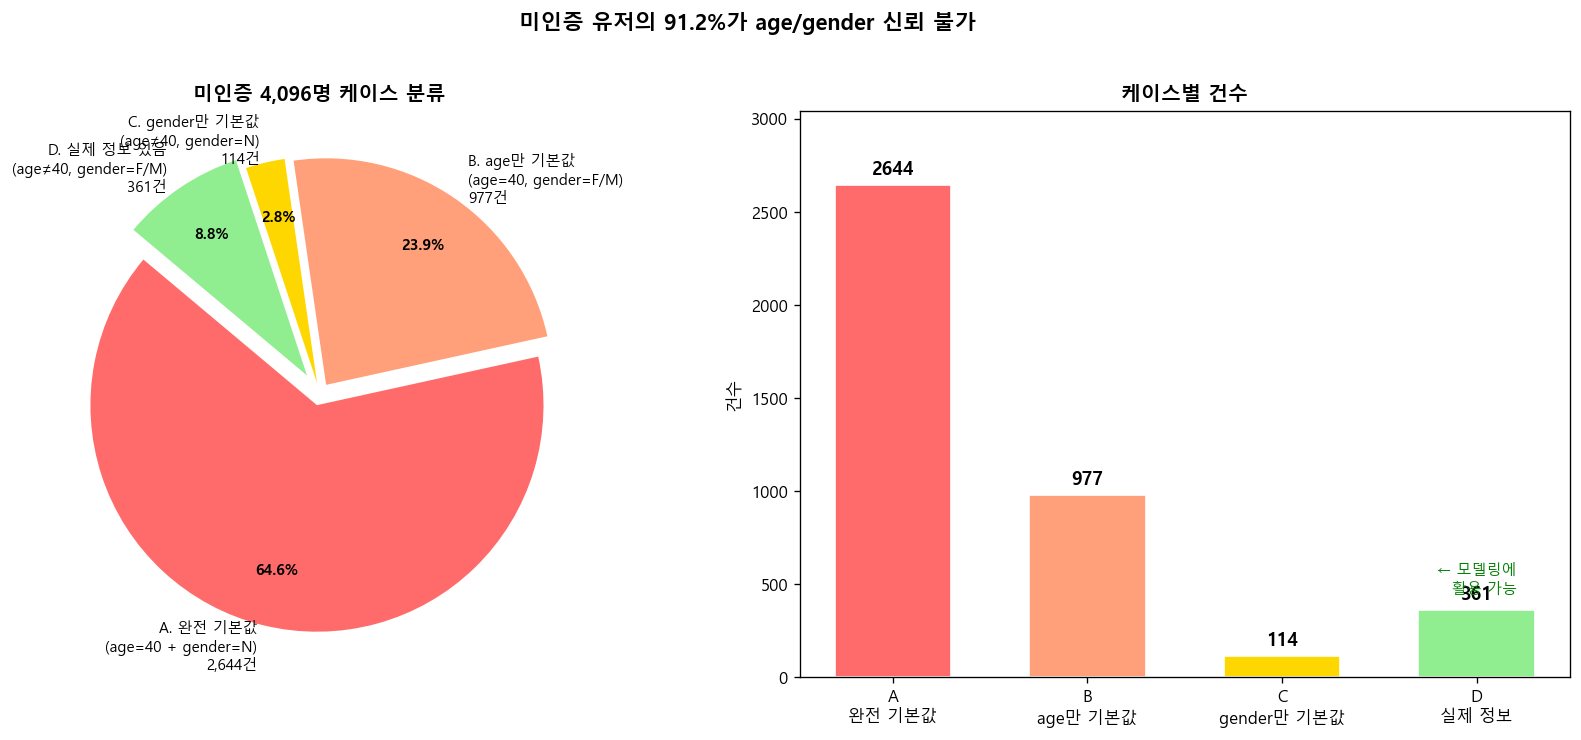

A (완전 기본값):    2,644건  (64.6%)
B (age만 기본값):     977건  (23.9%)
C (gender만 기본값):  114건  (2.8%)
D (실제 정보):        361건  (8.8%)


In [8]:
# 케이스 분류
caseA = unverified[(unverified['age'] == 40) & (unverified['gender'] == 'N')]   # 완전 기본값
caseB = unverified[(unverified['age'] == 40) & (unverified['gender'] != 'N')]   # age만 기본값
caseC = unverified[(unverified['age'] != 40) & (unverified['gender'] == 'N')]   # gender만 기본값
caseD = unverified[(unverified['age'] != 40) & (unverified['gender'] != 'N')]   # 실제 정보

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 파이차트
ax = axes[0]
labels_pie = [
    f'A. 완전 기본값\n(age=40 + gender=N)\n{len(caseA):,}건',
    f'B. age만 기본값\n(age=40, gender=F/M)\n{len(caseB):,}건',
    f'C. gender만 기본값\n(age≠40, gender=N)\n{len(caseC):,}건',
    f'D. 실제 정보 있음\n(age≠40, gender=F/M)\n{len(caseD):,}건',
]
sizes = [len(caseA), len(caseB), len(caseC), len(caseD)]
explode = (0.05, 0.05, 0.05, 0.1)
colors_pie = ['#FF6B6B', '#FFA07A', '#FFD700', '#90EE90']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_pie, autopct='%1.1f%%',
    explode=explode, colors=colors_pie,
    startangle=140, pctdistance=0.75,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('미인증 4,096명 케이스 분류', fontsize=12, fontweight='bold')

# 막대 차트
ax2 = axes[1]
case_labels = ['A\n완전 기본값', 'B\nage만 기본값', 'C\ngender만 기본값', 'D\n실제 정보']
case_colors = ['#FF6B6B', '#FFA07A', '#FFD700', '#90EE90']
bars3 = ax2.bar(case_labels, sizes, color=case_colors, edgecolor='white', width=0.6)
ax2.bar_label(bars3, padding=4, fontsize=11, fontweight='bold')
ax2.set_ylabel('건수')
ax2.set_title('케이스별 건수', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(sizes) * 1.15)

# 신뢰 불가 비율 주석
unreliable = len(caseA) + len(caseB) + len(caseC)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.text(3, len(caseD) * 1.25,
         f'← 모델링에\n   활용 가능',
         color='green', fontsize=9, ha='center')

plt.suptitle(f'미인증 유저의 {unreliable/len(unverified)*100:.1f}%가 age/gender 신뢰 불가',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'A (완전 기본값):    {len(caseA):>5,}건  ({len(caseA)/len(unverified)*100:.1f}%)')
print(f'B (age만 기본값):   {len(caseB):>5,}건  ({len(caseB)/len(unverified)*100:.1f}%)')
print(f'C (gender만 기본값):{len(caseC):>5,}건  ({len(caseC)/len(unverified)*100:.1f}%)')
print(f'D (실제 정보):      {len(caseD):>5,}건  ({len(caseD)/len(unverified)*100:.1f}%)')

---
## 7. 얼마나 왜곡됐는가 — 기본값 제거 전/후 age 분포 비교

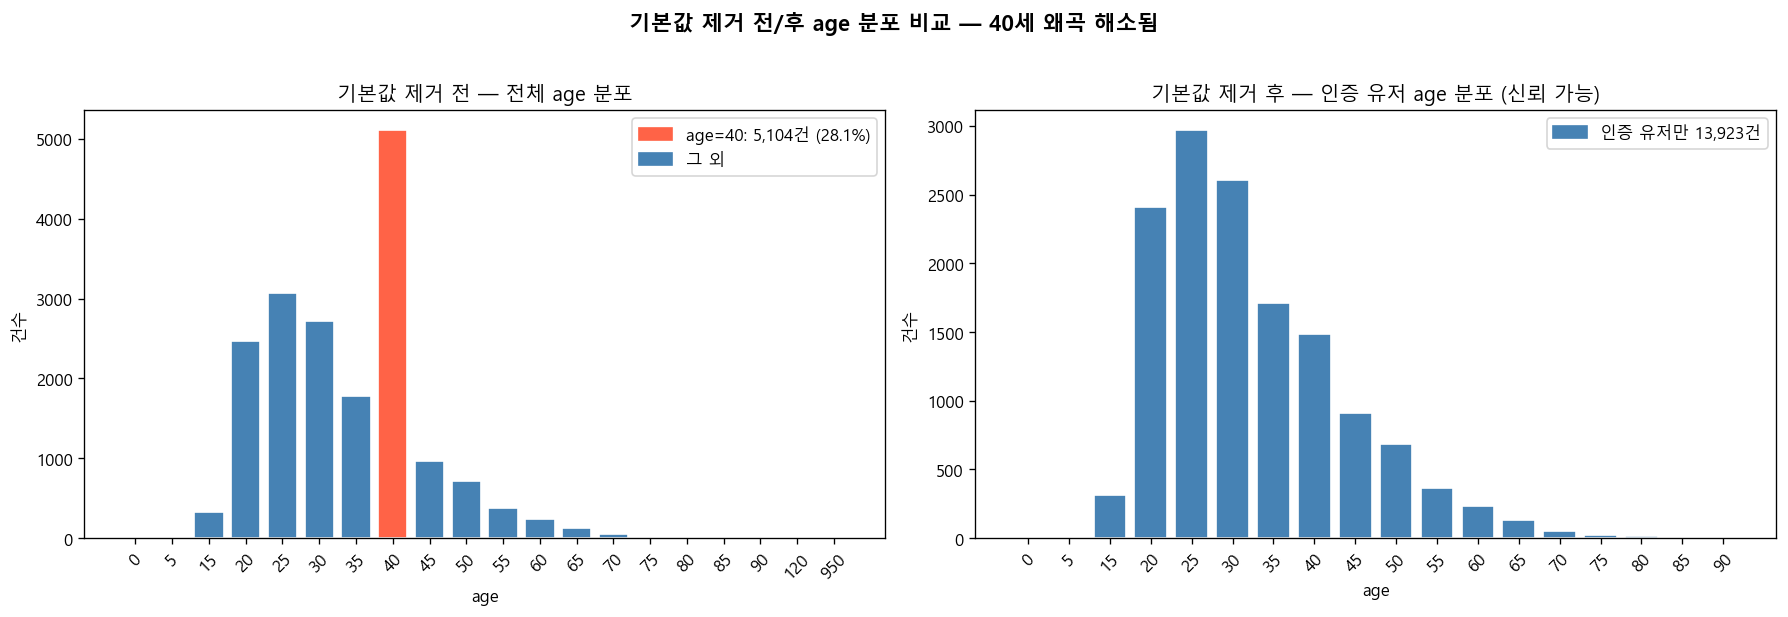

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 왼쪽: 기본값 제거 전 (현재 상태)
ax = axes[0]
all_age = df['age'].dropna()
all_age_counts = all_age.value_counts().sort_index()
bar_colors = ['tomato' if a == 40 else 'steelblue' for a in all_age_counts.index]
bars1 = ax.bar(all_age_counts.index.astype(int).astype(str),
               all_age_counts.values,
               color=bar_colors, edgecolor='white')
ax.set_title('기본값 제거 전 — 전체 age 분포')
ax.set_xlabel('age')
ax.set_ylabel('건수')
ax.tick_params(axis='x', rotation=45)
red_patch  = mpatches.Patch(color='tomato',    label=f'age=40: {(all_age==40).sum():,}건 (28.1%)')
blue_patch = mpatches.Patch(color='steelblue', label='그 외')
ax.legend(handles=[red_patch, blue_patch])

# 오른쪽: 기본값 제거 후 (미인증 age=40 → NaN 처리)
ax2 = axes[1]
df_clean = df.copy()
df_clean.loc[df_clean['is_user_verified'] == 'N', 'age'] = np.nan
clean_age = df_clean['age'].dropna()
clean_counts = clean_age.value_counts().sort_index()
bars2 = ax2.bar(clean_counts.index.astype(int).astype(str),
                clean_counts.values,
                color='steelblue', edgecolor='white')
ax2.set_title('기본값 제거 후 — 인증 유저 age 분포 (신뢰 가능)')
ax2.set_xlabel('age')
ax2.set_ylabel('건수')
ax2.tick_params(axis='x', rotation=45)
green_patch = mpatches.Patch(color='steelblue', label=f'인증 유저만 {len(clean_age):,}건')
ax2.legend(handles=[green_patch])

plt.suptitle('기본값 제거 전/후 age 분포 비교 — 40세 왜곡 해소됨', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. 전체 원인 구조 요약 — Stacked Bar

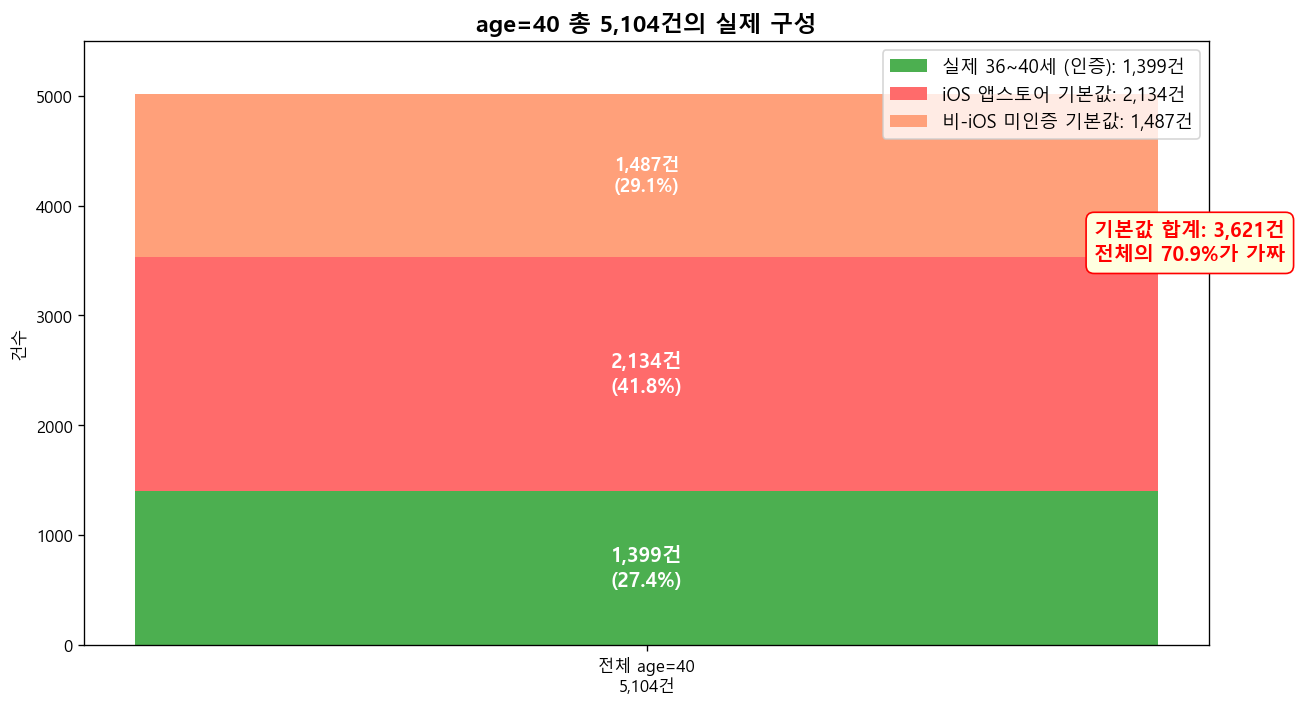

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

# age==40 건수 분해
real_age40    = (verified['age'] == 40).sum()          # 진짜 36~40세
ios_default   = ((unverified['billing_method'] == 140) & (unverified['age'] == 40)).sum()   # iOS 기본값
other_default = ((unverified['billing_method'] != 140) & (unverified['age'] == 40)).sum()   # 기타 기본값

categories = ['전체 age=40\n5,104건']
bar_real  = ax.bar(categories, real_age40,    color='#4CAF50',  label=f'실제 36~40세 (인증): {real_age40:,}건')
bar_ios   = ax.bar(categories, ios_default,   bottom=real_age40, color='#FF6B6B', label=f'iOS 앱스토어 기본값: {ios_default:,}건')
bar_other = ax.bar(categories, other_default, bottom=real_age40+ios_default, color='#FFA07A', label=f'비-iOS 미인증 기본값: {other_default:,}건')

# 라벨
ax.text(0, real_age40 / 2, f'{real_age40:,}건\n({real_age40/5104*100:.1f}%)', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text(0, real_age40 + ios_default / 2, f'{ios_default:,}건\n({ios_default/5104*100:.1f}%)', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text(0, real_age40 + ios_default + other_default / 2, f'{other_default:,}건\n({other_default/5104*100:.1f}%)', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_ylabel('건수')
ax.set_title('age=40 총 5,104건의 실제 구성', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 5500)

# 실제 vs 기본값 비율 주석
fake_total = ios_default + other_default
ax.annotate(f'기본값 합계: {fake_total:,}건\n전체의 {fake_total/5104*100:.1f}%가 가짜',
            xy=(0.35, 3500), fontsize=12, color='red', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='red'))

plt.tight_layout()
plt.show()

---
## 9. 결론 및 모델링 처리 방향

In [11]:
print('=' * 60)
print('        age=40 이상 현상 원인 분석 결론')
print('=' * 60)
print()
print('[근본 원인]')
print('  is_user_verified=N인 유저는 성별/연령이 부정확 (명세서 명시)')
print('  → 미인증 시 시스템이 age=40, gender=N을 기본값으로 자동 할당')
print()
print('[세부 원인]')
print(f'  원인1. iOS 앱스토어 결제(BM=140)')
print(f'         - 애플 정책: 구독자 개인정보 앱 미제공')
print(f'         - 해당 유저 {len(ios_unv):,}명 → age=40 자동 부여 (98.1%)')
print()
print(f'  원인2. 비-iOS 결제 후 본인인증 미실시')
print(f'         - Android/PC 등으로 가입했으나 인증 절차 생략')
print(f'         - 해당 유저 {len(nios_unv):,}명 → age=40 기본값 (77.4%)')
print()
print('[왜곡 규모]')
print(f'  전체 age=40: 5,104건')
print(f'  - 진짜 36~40세:     {real_age40:,}건 ({real_age40/5104*100:.1f}%)')
print(f'  - 기본값 (가짜): {fake_total:,}건 ({fake_total/5104*100:.1f}%)')
print()
print('[모델링 처리 권장]')
print('  1. is_user_verified=N인 경우 age, gender → NaN 처리')
print('  2. billing_method=140 (iOS) 여부를 별도 피처로 추가')
print('  3. gender=N도 NaN 처리 (미인증과 동일한 논리)')
print('  4. 인증 유저(13,487건)의 age/gender만 신뢰하여 모델 학습')

        age=40 이상 현상 원인 분석 결론

[근본 원인]
  is_user_verified=N인 유저는 성별/연령이 부정확 (명세서 명시)
  → 미인증 시 시스템이 age=40, gender=N을 기본값으로 자동 할당

[세부 원인]
  원인1. iOS 앱스토어 결제(BM=140)
         - 애플 정책: 구독자 개인정보 앱 미제공
         - 해당 유저 2,175명 → age=40 자동 부여 (98.1%)

  원인2. 비-iOS 결제 후 본인인증 미실시
         - Android/PC 등으로 가입했으나 인증 절차 생략
         - 해당 유저 1,921명 → age=40 기본값 (77.4%)

[왜곡 규모]
  전체 age=40: 5,104건
  - 진짜 36~40세:     1,399건 (27.4%)
  - 기본값 (가짜): 3,621건 (70.9%)

[모델링 처리 권장]
  1. is_user_verified=N인 경우 age, gender → NaN 처리
  2. billing_method=140 (iOS) 여부를 별도 피처로 추가
  3. gender=N도 NaN 처리 (미인증과 동일한 논리)
  4. 인증 유저(13,487건)의 age/gender만 신뢰하여 모델 학습
